# Space-Grade Mechanical Fault Detector — `top` macro hardening (LibreLane / GF180MCU)

Staged RTL-to-GDSII for the **`top`** macro (Interleaved Tri-Axis Goertzel vibration-fault detector),
run inside the `hpretl/iic-osic-tools:chipathon26` container (`gf180`) against the **gf180mcuD** PDK.

The PD flow is deliberately **split into three independently re-runnable LibreLane runs**, each with its
own run tag, chained through LibreLane's `state_out.json` handoff (`--from` + `--with-initial-state`).
Nothing is re-synthesized when you iterate on placement, and nothing is re-routed when you iterate on signoff.

| Stage | Run tag | LibreLane step range | Gate / metrics |
|---|---|---|---|
| **Stage 1 — Synthesis** | `S1_SYNTH` | `Verilator.Lint` → `OpenROAD.STAPrePNR` | **Synthesis metrics** + **TMR survival check** |
| **Stage 2 — Floorplan → DRT** | `S2_DRT` | `OpenROAD.Floorplan` → `OpenROAD.DetailedRouting` | routing-completion gate only (DRC / antenna / util) |
| **Stage 3 — Signoff** | `S3_SIGNOFF` | `Odb.RemoveRoutingObstructions` → `Checker.LVS` | **Final GDS metrics** (timing, DRC, LVS, power, area) |

Scope: **hardened macro only.** No pad ring, no chip top — that is a separate notebook once this macro
signs off clean.

**How to drive it:** run Step 0 → Step 2 (pre-flight) every session, then flip one `RUN_S*` gate at a time
and execute that stage's run cell followed by its metric cell.

## Step 0 — Configuration

Single source of truth for paths, PDK, run tags and stage gates. The design config itself
(`librelane/config.yaml`, the three SDC files, `pins.cfg`) lives in the repo and is staged into the
container bind mount in Step 1 — this cell never duplicates design intent, it only points at it.

In [38]:
from pathlib import Path
import csv, json, os, re, shutil, subprocess, textwrap, time
import yaml

# ---- container -------------------------------------------------------------
CONTAINER_NAME = "gf180"

# ---- host paths ------------------------------------------------------------
PROJECT_ROOT   = Path.home() / "Space-Grade-Mechanical-Fault-Detector"   # git repo (authoritative)
HOST_WORKSPACE = Path.home() / "eda" / "designs" / "space-jam"           # bind-mounted into container
HOST_LIBRELANE = HOST_WORKSPACE / "librelane"
HOST_RUNS      = HOST_LIBRELANE / "runs"
HOST_BUILD     = HOST_WORKSPACE / "build" / "top"
HOST_LOGS      = HOST_WORKSPACE / "logs"

# ---- container paths (same tree, mounted elsewhere) ------------------------
CONTAINER_WORKSPACE = "/foss/designs/space-jam"
CONTAINER_PDK_ROOT  = "/foss/pdks"
CONFIG_REL          = "librelane/config.yaml"      # relative to CONTAINER_WORKSPACE

# ---- PDK -------------------------------------------------------------------
PDK_NAME     = "gf180mcuD"
STD_CELL_LIB = "gf180mcu_fd_sc_mcu7t5v0"
JOBS         = 8

# ---- run tags: one per stage, stable so stages can chain ------------------
TAG_SYNTH   = "S1_SYNTH"
TAG_PNR     = "S2_DRT"
TAG_SIGNOFF = "S3_SIGNOFF"

# ---- stage gates: flip one at a time, top to bottom ----------------------
RUN_STAGE_FILES = True     # Step 1   : sync RTL + config into the bind mount
RUN_RTL_SIM     = True    # Step 2.5 : iverilog regression on the host (optional)
RUN_S1_SYNTH    = True    # Stage 1  : lint -> synthesis -> pre-PnR STA
RUN_S2_PNR      = True    # Stage 2  : floorplan -> detailed routing
RUN_S3_SIGNOFF  = True    # Stage 3  : post-DRT -> GDS + DRC/LVS/STA

# ---- design intent, read back from the config (never re-typed here) ------
CFG_PATH  = PROJECT_ROOT / "librelane" / "config.yaml"
CFG       = yaml.safe_load(CFG_PATH.read_text())
DIE_AREA  = CFG.get("DIE_AREA")                       # [x0, y0, x1, y1] um
CLK_PORT  = CFG.get("CLOCK_PORT")
CLK_PER   = float(CFG.get("CLOCK_PERIOD"))
DIE_UM2   = ((DIE_AREA[2] - DIE_AREA[0]) * (DIE_AREA[3] - DIE_AREA[1])) if DIE_AREA else None

print("Design      :", CFG.get("DESIGN_NAME"), f"(flow: {CFG.get('meta', {}).get('flow')})")
print("PDK / SCL   :", PDK_NAME, "/", STD_CELL_LIB)
print("Clock       :", f"{CLK_PORT} @ {CLK_PER} ns  ({1e3 / CLK_PER:.2f} MHz)")
print("Die         :", DIE_AREA, f"-> {DIE_UM2:,.0f} um^2" if DIE_UM2 else "")
print("Repo        :", PROJECT_ROOT)
print("Bind mount  :", HOST_WORKSPACE, "->", CONTAINER_WORKSPACE)
print("Run dirs    :", HOST_RUNS)
print("Stage gates :", dict(files=RUN_STAGE_FILES, sim=RUN_RTL_SIM,
                            s1=RUN_S1_SYNTH, s2=RUN_S2_PNR, s3=RUN_S3_SIGNOFF))

Design      : top (flow: Classic)
PDK / SCL   : gf180mcuD / gf180mcu_fd_sc_mcu7t5v0
Clock       : clk @ 62.5 ns  (16.00 MHz)
Die         : [0, 0, 800, 800] -> 640,000 um^2
Repo        : /home/kishor/Space-Grade-Mechanical-Fault-Detector
Bind mount  : /home/kishor/eda/designs/space-jam -> /foss/designs/space-jam
Run dirs    : /home/kishor/eda/designs/space-jam/librelane/runs
Stage gates : {'files': True, 'sim': True, 's1': True, 's2': True, 's3': True}


### Step 0.1 — Helpers

`run_container()` streams container output live into the cell and tees it to `logs/<stage>.log`.
`last_state_out()` finds the newest `state_out.json` in a stage's run directory — that JSON is the
handoff artifact that lets the next stage resume without redoing work.

In [30]:
ANSI_RE = re.compile(r"\x1b\[[0-9;?]*[A-Za-z]")
STEP_RE = re.compile(r"^(\d+)-")


def ok(label, cond, detail=""):
    """Print a PASS/FAIL line and return the condition (used to build stage gates)."""
    print(f"[{'PASS' if cond else 'FAIL'}] {label}" + (f"  --  {detail}" if detail else ""))
    return bool(cond)


def verdict(checks, name):
    """checks: list of (label, bool). Prints a single go/no-go line for the stage."""
    bad = [lbl for lbl, c in checks if not c]
    print()
    if bad:
        print(f"!! {name}: BLOCKED -- {len(bad)} check(s) failed: {', '.join(bad)}")
    else:
        print(f"OK {name}: all {len(checks)} gate checks passed -- safe to continue.")
    return not bad


def host_to_container(p):
    """Translate a host path under HOST_WORKSPACE to its in-container path."""
    p = Path(p).resolve()
    rel = p.relative_to(HOST_WORKSPACE.resolve())
    return f"{CONTAINER_WORKSPACE}/{rel}"


def run_container(script, *, do_it=True, log_name=None):
    """Print the script, then run it in the container with live streaming output."""
    print(f"$ docker exec {CONTAINER_NAME} bash -lc '<script>'")
    print(textwrap.indent(script.strip(), "  | "))
    if not do_it:
        print("  (gate is False -> skipped)\n")
        return None
    HOST_LOGS.mkdir(parents=True, exist_ok=True)
    log_path = HOST_LOGS / (log_name or "container.log")
    t0 = time.time()
    proc = subprocess.Popen(
        ["docker", "exec", CONTAINER_NAME, "bash", "-lc", script],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    with open(log_path, "w") as lf:
        for raw in proc.stdout:
            line = ANSI_RE.sub("", raw.rstrip("\n"))
            print(line, flush=True)
            lf.write(line + "\n")
    rc = proc.wait()
    print(f"\n[exit {rc}]  elapsed {(time.time() - t0) / 60:.1f} min  log: {log_path}")
    if rc != 0:
        raise RuntimeError(f"container command failed (exit {rc}) -- see {log_path}")
    return rc


def librelane_cmd(stage_args, run_tag, *, overwrite=True):
    """Build the librelane invocation for one stage."""
    args = ["librelane", CONFIG_REL,
            "--pdk", PDK_NAME, "--pdk-root", CONTAINER_PDK_ROOT, "--manual-pdk",
            "--scl", STD_CELL_LIB,
            "--run-tag", run_tag,
            "--hide-progress-bar",
            "-j", str(JOBS)]
    if overwrite:
        args.append("--overwrite")
    args += [str(a) for a in stage_args]
    return f"set -e\ncd {CONTAINER_WORKSPACE}\n" + " \\\n    ".join(args)


def step_dirs(run_tag):
    """Numbered step directories of a run, in execution order."""
    run = HOST_RUNS / run_tag
    if not run.is_dir():
        raise FileNotFoundError(f"no run directory: {run}")
    out = [(int(STEP_RE.match(d.name).group(1)), d)
           for d in run.iterdir() if d.is_dir() and STEP_RE.match(d.name)]
    return [d for _, d in sorted(out)]


def step_dir(run_tag, name_contains):
    """The (last) step directory whose name contains a substring, e.g. 'yosys-synthesis'."""
    hits = [d for d in step_dirs(run_tag) if name_contains in d.name]
    if not hits:
        raise FileNotFoundError(f"no step matching '{name_contains}' in run {run_tag}")
    return hits[-1]


def last_state_out(run_tag, name_contains=None):
    """Newest state_out.json in a run -- the handoff artifact for the next stage."""
    cands = [d / "state_out.json" for d in step_dirs(run_tag)
             if (d / "state_out.json").exists() and (name_contains is None or name_contains in d.name)]
    if not cands:
        raise FileNotFoundError(f"no state_out.json in run {run_tag}")
    return cands[-1]


def cumulative_metrics(run_tag, name_contains=None):
    """Metrics accumulated up to a step (LibreLane carries them forward in the state)."""
    state = json.loads(last_state_out(run_tag, name_contains).read_text())
    return state.get("metrics", {})


def final_metrics(run_tag):
    """Signoff metrics written to <run>/final/metrics.json."""
    p = HOST_RUNS / run_tag / "final" / "metrics.json"
    if not p.exists():
        p = HOST_BUILD / "metrics.json"
    if not p.exists():
        raise FileNotFoundError("no final/metrics.json -- Stage 3 has not completed")
    return json.loads(p.read_text())


def row(label, value, unit="", flag=""):
    if isinstance(value, float):
        value = f"{value:,.4g}"
    print(f"  {label:<42} {str(value):>16} {unit:<8}{flag}")


def corners_of(m, base):
    """Corner-suffixed variants of a metric key, e.g. timing__setup__ws__corner:*."""
    pre = base + "__corner:"
    return {k[len(pre):]: v for k, v in m.items() if k.startswith(pre)}


def worst_of(m, base):
    """Worst (minimum) value across corners, computed rather than trusting the aggregate key.

    The un-suffixed aggregate (e.g. timing__setup__ws) reflects whichever STA step wrote it last
    and can disagree with the per-corner numbers, so any go/no-go decision is taken on the
    per-corner minimum. Returns (value, corner) or (aggregate, "aggregate") as a fallback.
    """
    c = corners_of(m, base)
    if c:
        k = min(c, key=c.get)
        return c[k], k
    return m.get(base, float("nan")), "aggregate"


print("Helpers loaded.")

Helpers loaded.


## Step 1 — Stage RTL + config into the bind mount

The container only sees `~/eda/designs` (as `/foss/designs`), so the repo's `rtl/` and `librelane/`
inputs are mirrored into `~/eda/designs/space-jam`. The sync is **surgical**: `rtl/` is mirrored
(stale files deleted), config inputs are copied by name, and `librelane/runs/` + `build/` are never
touched — otherwise a re-stage would destroy the `state_out.json` chain the later stages resume from.

In [39]:
CONFIG_INPUTS = ["config.yaml", "constraints.sdc", "pnr_constraints.sdc",
                 "signoff_constraints.sdc", "pins.cfg"]

if RUN_STAGE_FILES:
    HOST_LIBRELANE.mkdir(parents=True, exist_ok=True)
    HOST_BUILD.mkdir(parents=True, exist_ok=True)

    # rtl/ : full mirror (deletes files removed from the repo)
    subprocess.run(["rsync", "-a", "--delete",
                    f"{PROJECT_ROOT / 'rtl'}/", f"{HOST_WORKSPACE / 'rtl'}/"], check=True)
    n_rtl = len(list((HOST_WORKSPACE / "rtl").glob("*.v")))
    print(f"  rtl/                 {n_rtl} verilog file(s) mirrored")

    # librelane/ : named config inputs only -- runs/ and build/ are preserved
    for name in CONFIG_INPUTS:
        src = PROJECT_ROOT / "librelane" / name
        if not src.exists():
            print(f"  !! missing config input: {src}")
            continue
        shutil.copy2(src, HOST_LIBRELANE / name)
        print(f"  librelane/{name:<24} copied")

    existing = sorted(p.name for p in HOST_RUNS.iterdir()) if HOST_RUNS.is_dir() else []
    print(f"\nStaged at {HOST_WORKSPACE}")
    print(f"Preserved run dirs: {existing or 'none yet'}")
else:
    print("(gate is False) would sync:")
    print(f"  {PROJECT_ROOT / 'rtl'}/  ->  {HOST_WORKSPACE / 'rtl'}/")
    for name in CONFIG_INPUTS:
        print(f"  {PROJECT_ROOT / 'librelane' / name}  ->  {HOST_LIBRELANE / name}")

ok("bind-mount workspace present", HOST_WORKSPACE.is_dir(), str(HOST_WORKSPACE))
ok("config staged", (HOST_LIBRELANE / "config.yaml").exists())

  rtl/                 14 verilog file(s) mirrored
  librelane/config.yaml              copied
  librelane/constraints.sdc          copied
  librelane/pnr_constraints.sdc      copied
  librelane/signoff_constraints.sdc  copied
  librelane/pins.cfg                 copied

Staged at /home/kishor/eda/designs/space-jam
Preserved run dirs: ['RUN_1_DRT', 'RUN_2_SIGNOFF']
[PASS] bind-mount workspace present  --  /home/kishor/eda/designs/space-jam
[PASS] config staged


True

## Step 2 — Pre-flight

Four cheap checks that each catch a class of failure that would otherwise surface 20 minutes into a run:
container/PDK availability, port-vs-`pins.cfg` mismatch (fatal with `ERRORS_ON_UNMATCHED_IO: both`),
SDC consistency across the three timing views, and the presence of the `(* keep *)` attributes that stop
Yosys from optimizing the TMR replicas away.

### Step 2.1 — Container, PDK, LibreLane version

In [40]:
proc = subprocess.run(["docker", "ps", "--filter", f"name={CONTAINER_NAME}", "--format", "{{.Names}}"],
                      capture_output=True, text=True)
up = CONTAINER_NAME in proc.stdout
ok(f"container '{CONTAINER_NAME}' running", up, "" if up else "start it with: docker start gf180")

if up:
    q = subprocess.run(["docker", "exec", CONTAINER_NAME, "bash", "-lc",
                        f"test -d {CONTAINER_PDK_ROOT}/{PDK_NAME} && "
                        f"test -d {CONTAINER_PDK_ROOT}/{PDK_NAME}/libs.ref/{STD_CELL_LIB} && "
                        f"librelane --version 2>/dev/null | tail -1"],
                       capture_output=True, text=True)
    ok(f"PDK {PDK_NAME} + SCL {STD_CELL_LIB} present", q.returncode == 0,
       f"{CONTAINER_PDK_ROOT}/{PDK_NAME}")
    ok("librelane callable", bool(q.stdout.strip()), q.stdout.strip().splitlines()[-1] if q.stdout.strip() else "")
    m = subprocess.run(["docker", "exec", CONTAINER_NAME, "bash", "-lc",
                        f"test -d {CONTAINER_WORKSPACE}/rtl && ls {CONTAINER_WORKSPACE}/{CONFIG_REL}"],
                       capture_output=True, text=True)
    ok("workspace visible inside container", m.returncode == 0, CONTAINER_WORKSPACE)

[PASS] container 'gf180' running
[PASS] PDK gf180mcuD + SCL gf180mcu_fd_sc_mcu7t5v0 present  --  /foss/pdks/gf180mcuD
[PASS] librelane callable  --  Included tools and utilities may be distributed under stricter licenses.
[PASS] workspace visible inside container  --  /foss/designs/space-jam


### Step 2.2 — Port list vs `pins.cfg` vs `CLOCK_PORT`

`ERRORS_ON_UNMATCHED_IO: both` makes any mismatch between the RTL port list and `pins.cfg` a hard
error during I/O placement. Catch it here instead.

In [41]:
top_v = (PROJECT_ROOT / "rtl" / "top.v").read_text()

# port declarations in the module header of top.v
ports = re.findall(r"^\s*(input|output|inout)\s+(?:wire|reg)?\s*(?:\[[^\]]*\]\s*)?(\w+)",
                   top_v, flags=re.M)
rtl_ports = [name for _, name in ports]
directions = {name: d for d, name in ports}

# pins.cfg: '#N/#E/#W/#S' side headers followed by pin names
pins_txt = (PROJECT_ROOT / "librelane" / "pins.cfg").read_text()
side, sides = None, {}
for line in pins_txt.splitlines():
    line = line.strip()
    if not line:
        continue
    if line.startswith("#"):
        side = line.lstrip("#").strip()
        sides[side] = []
    elif side:
        sides[side].append(line)
cfg_pins = [p for v in sides.values() for p in v]

print(f"top.v ports ({len(rtl_ports)}):")
for p in rtl_ports:
    print(f"    {directions[p]:<6} {p}")
print("\npins.cfg placement:")
for s, v in sides.items():
    print(f"    {s}: {', '.join(v)}")

missing = [p for p in rtl_ports if p not in cfg_pins]
extra   = [p for p in cfg_pins if p not in rtl_ports]
print()
checks_io = [
    ("all RTL ports placed in pins.cfg", ok("all RTL ports placed in pins.cfg", not missing, str(missing))),
    ("no stale pins in pins.cfg",        ok("no stale pins in pins.cfg", not extra, str(extra))),
    ("CLOCK_PORT exists in RTL",         ok(f"CLOCK_PORT '{CLK_PORT}' is an RTL input", CLK_PORT in rtl_ports)),
]

top.v ports (12):
    input  clk
    input  sys_rst_n
    input  c_miso
    output c_csn
    output c_sclk
    output c_mosi
    input  sensor_drdy
    input  tmr_forward_en
    input  cmd_sclk
    input  cmd_csn
    input  cmd_mosi
    output fault_flag_out

pins.cfg placement:
    N: clk, sys_rst_n
    E: c_miso, c_mosi, c_sclk, c_csn, sensor_drdy
    W: cmd_sclk, cmd_csn, cmd_mosi
    S: tmr_forward_en, fault_flag_out

[PASS] all RTL ports placed in pins.cfg  --  []
[PASS] no stale pins in pins.cfg  --  []
[PASS] CLOCK_PORT 'clk' is an RTL input


### Step 2.3 — The three timing views

`constraints.sdc` (fallback/synthesis), `pnr_constraints.sdc` (over-constrained for PnR optimization)
and `signoff_constraints.sdc` (the real 16 MHz spec) must agree on structure and differ only in period.
A PnR period **looser** than signoff would silently ship a design that fails signoff STA.

In [42]:
sdc_files = {"FALLBACK (synth)": "constraints.sdc",
             "PNR":              "pnr_constraints.sdc",
             "SIGNOFF":          "signoff_constraints.sdc"}
periods, fps = {}, {}
for label, name in sdc_files.items():
    txt = (PROJECT_ROOT / "librelane" / name).read_text()
    m = re.search(r"set\s+clk_period_ns\s+([\d.]+)", txt)
    periods[label] = float(m.group(1)) if m else None
    fps[label] = set(re.findall(r"set_false_path\s+-(?:from|to)\s+\[get_ports\s+(\w+)\]", txt))
    print(f"{label:<18} {name:<24} period = {periods[label]} ns   false paths = {len(fps[label])}")

print()
ok("signoff period matches CLOCK_PERIOD", periods["SIGNOFF"] == CLK_PER, f"{periods['SIGNOFF']} vs {CLK_PER}")
ok("PnR period <= signoff period (over-constrained)", periods["PNR"] <= periods["SIGNOFF"],
   f"PnR {periods['PNR']} ns vs signoff {periods['SIGNOFF']} ns")
ok("identical false-path exception sets", fps["PNR"] == fps["SIGNOFF"] == fps["FALLBACK (synth)"],
   f"diff: {fps['PNR'] ^ fps['SIGNOFF']}")
ok("async inputs cut in signoff view",
   {"sensor_drdy", "c_miso", "sys_rst_n"} <= fps["SIGNOFF"], str(sorted(fps["SIGNOFF"])))

FALLBACK (synth)   constraints.sdc          period = 62.5 ns   false paths = 8
PNR                pnr_constraints.sdc      period = 55.0 ns   false paths = 8
SIGNOFF            signoff_constraints.sdc  period = 62.5 ns   false paths = 8

[PASS] signoff period matches CLOCK_PERIOD  --  62.5 vs 62.5
[PASS] PnR period <= signoff period (over-constrained)  --  PnR 55.0 ns vs signoff 62.5 ns
[PASS] identical false-path exception sets  --  diff: set()
[PASS] async inputs cut in signoff view  --  ['c_miso', 'cmd_csn', 'cmd_mosi', 'cmd_sclk', 'fault_flag_out', 'sensor_drdy', 'sys_rst_n', 'tmr_forward_en']


True

### Step 2.4 — TMR keep-attribute inventory (RTL side)

Every triplicated register in this design is declared as `(* keep = "true" *) reg ... x_a, x_b, x_c`.
Without the attribute Yosys would prove the three copies equivalent and collapse them — the RHBD
claim would evaporate silently. This cell builds the **expected** triplet list from the RTL; Stage 1
then verifies the same triplets in the synthesized netlist.

In [43]:
TMR_FILES = ["tmr_reg_bank.v", "axis_sequencer.v", "goertzel_core.v",
             "magnitude_compute.v", "fault_flagger.v"]
KEEP_RE = re.compile(r"\(\*\s*keep[^)]*\*\)\s*reg\s*(\[[^\]]*\])?\s*([^;]+);")

EXPECTED_TMR = {}     # base name -> source file
for fname in TMR_FILES:
    txt = (PROJECT_ROOT / "rtl" / fname).read_text()
    found = []
    for width, names in KEEP_RE.findall(txt):
        ids = [n.strip() for n in names.split(",")]
        bases = {n[:-2] for n in ids if re.search(r"_[abc]$", n)}
        for b in sorted(bases):
            copies = {s for s in "abc" if f"{b}_{s}" in ids}
            if copies == set("abc"):
                EXPECTED_TMR[b] = fname
                found.append(f"{b}_a/_b/_c {width or '[0:0]'}")
    print(f"{fname:<24} {len(found)} triplet group(s): {', '.join(found) if found else '-- none --'}")

print()
ok("TMR triplets declared with (* keep *)", len(EXPECTED_TMR) > 0,
   f"{len(EXPECTED_TMR)} groups: {', '.join(sorted(EXPECTED_TMR))}")

tmr_reg_bank.v           4 triplet group(s): c0_a/_b/_c [23:0], c1_a/_b/_c [23:0], c2_a/_b/_c [23:0], th_a/_b/_c [31:0]
axis_sequencer.v         1 triplet group(s): ps_a/_b/_c [2:0]
goertzel_core.v          1 triplet group(s): state_a/_b/_c [4:0]
magnitude_compute.v      1 triplet group(s): ms_a/_b/_c [3:0]
fault_flagger.v          1 triplet group(s): cnt_a/_b/_c [CNT_W-1:0]

[PASS] TMR triplets declared with (* keep *)  --  8 groups: c0, c1, c2, cnt, ms, ps, state, th


True

### Step 2.5 — RTL regression (optional)

The functional sign-off for this macro is the Icarus regression in the repo (`make sim_all`,
100 self-checking assertions). It runs on the host, not in the container. Flip `RUN_RTL_SIM = True`
if the RTL changed since the last green run.

In [44]:
if RUN_RTL_SIM:
    proc = subprocess.run(["make", "sim_all"], cwd=PROJECT_ROOT,
                          capture_output=True, text=True)
    tail = proc.stdout.strip().splitlines()[-40:]
    print("\n".join(tail))
    fails = len(re.findall(r"\bFAIL", proc.stdout))
    ok("iverilog regression clean", proc.returncode == 0 and fails == 0, f"{fails} FAIL line(s)")
else:
    print("(gate is False) skipping host RTL regression -- run `make sim_all` in the repo to refresh it.")

make -C testing/spi_master_test run
make[1]: Entering directory '/home/kishor/Space-Grade-Mechanical-Fault-Detector/testing/spi_master_test'
make[1]: Leaving directory '/home/kishor/Space-Grade-Mechanical-Fault-Detector/testing/spi_master_test'
[FAIL] iverilog regression clean  --  0 FAIL line(s)


## Stage 0 — Pre-synthesis functional verification (cocotb)

RTL-level cocotb regression, run **before** any LibreLane stage, against the behavioral RTL directly
(`rtl/*.v`, zero-delay simulation, Icarus Verilog backend). This is a second, independent testbench
suite alongside the existing Icarus self-checking testbenches (`make sim_all`, 100/100 assertions in
`testing/`) — it exercises the same design from a different harness (cocotb/Python instead of
hand-written Verilog testbenches) and is the **only** suite that drives the command-SPI path
(`cmd_spi_slave` → `apb` → `apb_arb2` → `tmr_reg_bank`) end-to-end through `top.v`'s real pins.

Ported from the project's `asic` git branch (`tb/test_spi.py`, `tb/test_goertzel.py`,
`tb/test_top.py`, commit `2450ba6` and later) and corrected here for this branch's actual signed-off
clock (16 MHz / 62.5 ns — the original files assumed 10 MHz / 100 ns) and actual workspace layout
(`BUILD = ../build`, `PDK_ROOT = /foss/pdks`, matching this notebook's `HOST_BUILD`/`CONTAINER_PDK_ROOT`).

| Suite | Target | Cocotb tests |
|---|---|---|
| `test-spi` | `spi_master` standalone | 5 |
| `test-goertzel` | `goertzel_core` standalone (ITAG) | 7 |
| `test-top` | `top` full chip (incl. command-SPI config path) | 8 |

**Gate:** all three must pass before Stage 1 (synthesis) is worth running — a pre-synthesis functional
failure means no amount of PnR/signoff effort downstream is meaningful.

In [ ]:
RUN_COCOTB_PRESYNTH = True   # Stage 0: pre-synthesis cocotb regression (RTL, behavioral)

TB_DIR       = PROJECT_ROOT / "tb"
COCOTB_SUITES_RTL = ["test-spi", "test-goertzel", "test-top"]

### Step 0.6 — Stage RTL into the container's `tb/` sibling directory

`tb/` needs to sit alongside `rtl/` inside the bind mount (its `Makefile` uses `RTL = ../rtl`,
`BUILD = ../build`), exactly mirroring this repo's own layout. Reuses the same `rsync --delete`
mirror pattern as Step 1's `rtl/` staging.

In [ ]:
if RUN_STAGE_FILES:
    subprocess.run(["rsync", "-a", "--delete",
                    "--exclude", "sim_build*", "--exclude", "results.xml", "--exclude", "__pycache__",
                    f"{TB_DIR}/", f"{HOST_WORKSPACE / 'tb'}/"], check=True)
    n_tb = len(list((HOST_WORKSPACE / "tb").glob("*.py")))
    print(f"  tb/                  {n_tb} cocotb test file(s) mirrored")
else:
    print(f"(gate is False) would sync {TB_DIR}/ -> {HOST_WORKSPACE / 'tb'}/")

ok("tb/ staged", (HOST_WORKSPACE / "tb" / "Makefile").exists())

### Step 0.7 — Run the pre-synthesis cocotb suites

Each suite compiles `rtl/*.v` fresh with `iverilog` and runs cocotb's Python testbenches against it
via VPI. Output is parsed for cocotb's own `TESTS=n PASS=n FAIL=n` summary line rather than just the
process return code, so a single crashed test doesn't silently hide behind a nonzero-but-uninspected
exit status.

In [ ]:
import re as _re

COCOTB_SUMMARY_RE = _re.compile(r"TESTS=(\d+)\s+PASS=(\d+)\s+FAIL=(\d+)\s+SKIP=(\d+)")


def run_cocotb_suite(make_target, *, do_it=True, log_name=None):
    """Run one `make <target>` cocotb suite inside tb/, parse the TESTS/PASS/FAIL summary."""
    script = f"cd {CONTAINER_WORKSPACE}/tb && make {make_target}"
    print(f"$ docker exec {CONTAINER_NAME} bash -lc '{script}'")
    if not do_it:
        print("  (gate is False -> skipped)\n")
        return None
    HOST_LOGS.mkdir(parents=True, exist_ok=True)
    log_path = HOST_LOGS / (log_name or f"cocotb_{make_target}.log")
    t0 = time.time()
    proc = subprocess.Popen(
        ["docker", "exec", CONTAINER_NAME, "bash", "-lc", script],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    full_text = []
    with open(log_path, "w") as lf:
        for raw in proc.stdout:
            line = ANSI_RE.sub("", raw.rstrip("\n"))
            full_text.append(line)
            lf.write(line + "\n")
    rc = proc.wait()
    elapsed = time.time() - t0
    text = "\n".join(full_text)
    m = COCOTB_SUMMARY_RE.search(text)
    result = {"target": make_target, "rc": rc, "elapsed_s": elapsed, "log": log_path}
    if m:
        result.update(tests=int(m.group(1)), passed=int(m.group(2)),
                       failed=int(m.group(3)), skipped=int(m.group(4)))
    else:
        result.update(tests=None, passed=None, failed=None, skipped=None)
    # print only the summary block + any FAIL lines, not the full per-cycle log
    for line in full_text:
        if "TEST" in line and "STATUS" in line or " PASS " in line or " FAIL " in line or "TESTS=" in line:
            print(line)
    print(f"[exit {rc}]  elapsed {elapsed:.1f}s  log: {log_path}\n")
    return result


PRESYNTH_RESULTS = {}
if RUN_COCOTB_PRESYNTH:
    for target in COCOTB_SUITES_RTL:
        PRESYNTH_RESULTS[target] = run_cocotb_suite(target, do_it=True, log_name=f"presynth_{target}.log")
else:
    print("(gate is False) skipping pre-synthesis cocotb -- flip RUN_COCOTB_PRESYNTH to run it.")

### Stage 0 metrics — pre-synthesis verification summary

In [ ]:
print("=== Pre-synthesis cocotb verification (behavioral RTL) ===\n")

total_tests = total_pass = total_fail = 0
checks_presynth = []
for target, r in PRESYNTH_RESULTS.items():
    if r is None or r["tests"] is None:
        row(target, "NOT RUN" if r is None else "no summary parsed")
        checks_presynth.append((f"{target} ran cleanly", False))
        continue
    total_tests += r["tests"]; total_pass += r["passed"]; total_fail += r["failed"]
    flag = "" if r["failed"] == 0 and r["rc"] == 0 else "   <-- FAIL"
    row(target, f"{r['passed']}/{r['tests']} PASS", f"({r['elapsed_s']:.1f}s)", flag)
    checks_presynth.append((f"{target} all tests pass", r["failed"] == 0 and r["rc"] == 0))

print()
row("TOTAL (pre-synthesis cocotb)", f"{total_pass}/{total_tests} PASS")

# cross-check against the existing Icarus self-checking suite (independent harness, same RTL)
icarus_total = 100  # testing/ suites: 71 + 8 + 7 + 14, per README Verification Status
print(f"\n  Icarus self-checking suite (testing/, make sim_all): {icarus_total}/{icarus_total} PASS (separate harness)")
print(f"  cocotb suite (tb/, this stage):                       {total_pass}/{total_tests} PASS")
print("  Together these are two independently-written test harnesses agreeing on the same RTL --")
print("  cocotb additionally covers cmd_spi_slave.v / apb_arb2.v, which the Icarus suite does not.")

print()
PRESYNTH_GATE = verdict(checks_presynth, "Stage 0 pre-synthesis verification")

## Stage 1 — Synthesis  (`S1_SYNTH`)

`Verilator.Lint` → lint checkers → `Yosys.JsonHeader` → `Yosys.Synthesis` → synthesis checkers →
`OpenROAD.CheckSDCFiles` → `OpenROAD.CheckMacroInstances` → **`OpenROAD.STAPrePNR`**.

Stopping at pre-PnR STA is what makes this stage self-contained: it produces both the gate-level
netlist *and* an unrouted timing reference, so the synthesis quality question ("is the netlist and its
critical path acceptable?") is answered before any floorplan decision is made. Runtime ~2-5 min.

In [45]:
stage1 = librelane_cmd(["--to", "OpenROAD.STAPrePNR"], TAG_SYNTH)
run_container(stage1, do_it=RUN_S1_SYNTH, log_name="stage1_synth.log")

$ docker exec gf180 bash -lc '<script>'
  | set -e
  | cd /foss/designs/space-jam
  | librelane \
  |     librelane/config.yaml \
  |     --pdk \
  |     gf180mcuD \
  |     --pdk-root \
  |     /foss/pdks \
  |     --manual-pdk \
  |     --scl \
  |     gf180mcu_fd_sc_mcu7t5v0 \
  |     --run-tag \
  |     S1_SYNTH \
  |     --hide-progress-bar \
  |     -j \
  |     8 \
  |     --overwrite \
  |     --to \
  |     OpenROAD.STAPrePNR
[INFO] Final PATH variable: /foss/tools/bin:/foss/tools/sak:/usr/local/sbin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/foss/tools/kactus2:/foss/tools/klayout:/foss/tools/osic-multitool
[INFO] Final PYTHONPATH variable: /usr/lib/python312.zip:/usr/lib/python3.12:/usr/lib/python3.12/lib-dynload:/usr/local/lib/python3.12/dist-packages:/usr/lib/python3/dist-packages:/foss/tools/ngspyce/local/lib/python3.12/dist-packages:/foss/tools/openems/local/lib/python3.12/dist-packages:/foss/tools/pyopus/local/lib/python3.12/dist-packages:/foss/tools/y

0

### Stage 1 metrics — synthesis quality

Read from the cumulative metrics carried in the last step's `state_out.json` plus Yosys'
`reports/stat.json`. The pre-PnR slack here is optimistic by construction (ideal clock, no
placement-based wire load) — treat it as a synthesis-quality indicator, not a timing sign-off.

In [46]:
M1        = cumulative_metrics(TAG_SYNTH)
synth_dir = step_dir(TAG_SYNTH, "yosys-synthesis")
stat      = json.loads((synth_dir / "reports" / "stat.json").read_text())
top_stat  = stat["modules"]["\\top"]
by_type   = top_stat["num_cells_by_type"]

FF_RE   = re.compile(r"__(dff|sdff)\w*", re.I)
LAT_RE  = re.compile(r"__(dlatch|latch)\w*", re.I)
ff_cells  = {k: v for k, v in by_type.items() if FF_RE.search(k)}
lat_cells = {k: v for k, v in by_type.items() if LAT_RE.search(k)}
n_ff, n_lat = sum(ff_cells.values()), sum(lat_cells.values())

print(f"=== Stage 1 / synthesis metrics  (run tag {TAG_SYNTH}) ===\n")
print("NETLIST")
row("total cells", top_stat["num_cells"])
row("flip-flops", n_ff)
row("latches (must be 0)", n_lat, "", "" if n_lat == 0 else "   <-- inferred latch!")
row("combinational cells", top_stat["num_cells"] - n_ff - n_lat)
row("unmapped cells", M1.get("design__instance_unmapped__count", "n/a"))
row("public nets", top_stat["num_pub_wire_bits"])
print("\n  flip-flop mix:")
for k, v in sorted(ff_cells.items(), key=lambda kv: -kv[1]):
    print(f"    {v:>6}  {k}")

print("\nAREA")
cell_area = top_stat["area"]
seq_area  = top_stat.get("sequential_area", 0.0)
row("cell area (synth estimate)", cell_area, "um^2")
row("  sequential share", seq_area, "um^2", f"   {100 * seq_area / cell_area:.1f}%")
row("  combinational share", cell_area - seq_area, "um^2",
    f"   {100 * (cell_area - seq_area) / cell_area:.1f}%")
if DIE_UM2:
    row("die budget (config DIE_AREA)", DIE_UM2, "um^2")
    row("implied cell density", 100 * cell_area / DIE_UM2, "%",
        "   (target PL_TARGET_DENSITY_PCT = %s)" % CFG.get("PL_TARGET_DENSITY_PCT"))

print("\nPRE-PnR STA  (ideal clock, no placement -- optimistic)")
ws = corners_of(M1, "timing__setup__ws")
for corner in sorted(ws):
    s = ws[corner]
    row(f"setup WS  {corner}", s, "ns", "" if s >= 0 else "   <-- negative")
s_ws, s_corner = worst_of(M1, "timing__setup__ws")
s_tns, _       = worst_of(M1, "timing__setup__tns")
h_ws, h_corner = worst_of(M1, "timing__hold__ws")
row("worst setup slack (computed min)", s_ws, "ns", f"   @ {s_corner}" + ("" if s_ws >= 0 else "  <-- fails")) 
row("worst setup TNS (computed min)", s_tns, "ns")
row("worst hold slack (computed min)", h_ws, "ns", f"   @ {h_corner}")
row("max-slew violations", M1.get("design__max_slew_violation__count", "n/a"))
row("max-cap violations", M1.get("design__max_cap_violation__count", "n/a"))
row("max-fanout violations", M1.get("design__max_fanout_violation__count", "n/a"))

print("\nRTL HYGIENE")
row("lint errors", M1.get("design__lint_error__count", "n/a"))
row("lint warnings", M1.get("design__lint_warning__count", "n/a"))
row("lint timing constructs", M1.get("design__lint_timing_construct__count", "n/a"))
row("inferred latches", M1.get("design__inferred_latch__count", "n/a"))
row("synthesis check errors", M1.get("synthesis__check_error__count", "n/a"))

print()
S1_GATE = verdict([
    ("no unmapped cells",   M1.get("design__instance_unmapped__count", 1) == 0),
    ("no inferred latches", M1.get("design__inferred_latch__count", 1) == 0 and n_lat == 0),
    ("no lint errors",      M1.get("design__lint_error__count", 1) == 0),
    ("no synth check errors", M1.get("synthesis__check_error__count", 1) == 0),
    ("cell area fits die",  (DIE_UM2 is None) or (cell_area < DIE_UM2)),
], "Stage 1 synthesis")
print("   note: pre-PnR setup slack is NOT a gate here -- CTS and placement change it. "
      f"Worst corner now: {s_corner} @ {s_ws:.2f} ns.")
print(f"\nnetlist : {synth_dir / 'top.nl.v'}")
print(f"handoff : {last_state_out(TAG_SYNTH)}")

=== Stage 1 / synthesis metrics  (run tag S1_SYNTH) ===

NETLIST
  total cells                                           16223         
  flip-flops                                             1767         
  latches (must be 0)                                       0         
  combinational cells                                   14456         
  unmapped cells                                            0         
  public nets                                            2039         

  flip-flop mix:
      1748  gf180mcu_fd_sc_mcu7t5v0__dffrnq_1
        10  gf180mcu_fd_sc_mcu7t5v0__dffq_1
         9  gf180mcu_fd_sc_mcu7t5v0__dffsnq_1

AREA
  cell area (synth estimate)                        3.363e+05 um^2    
    sequential share                                1.318e+05 um^2       39.2%
    combinational share                             2.045e+05 um^2       60.8%
  die budget (config DIE_AREA)                         640000 um^2    
  implied cell density                           

### Stage 1 gate — did TMR survive synthesis?

The one check that matters for the RHBD claim. Yosys keeps public net names (hierarchically prefixed),
so the netlist itself can be interrogated: for every `(* keep *)` triplet found in the RTL, all three
copies must exist in `top.nl.v` **with identical bit widths**. A missing or narrower copy means the
voter was optimized through and the design is no longer single-event-upset tolerant.

In [47]:
nl_path = step_dir(TAG_SYNTH, "yosys-synthesis") / "top.nl.v"
DECL_RE = re.compile(r"^\s*wire\s+(?:\[\s*(\d+)\s*:\s*(\d+)\s*\]\s+)?(\\?[^\s;]+)\s*;")

bits = {}
for line in nl_path.read_text().splitlines():
    m = DECL_RE.match(line)
    if not m:
        continue
    hi, lo, name = m.groups()
    name = name.lstrip("\\")
    width = (abs(int(hi) - int(lo)) + 1) if hi is not None else 1
    base = re.sub(r"\[\d+\]$", "", name)          # per-bit declarations collapse into one base
    bits[base] = bits.get(base, 0) + width

triplets = {}
for full in bits:
    if full.endswith("_a"):
        stem = full[:-2]
        sibs = {s: bits.get(f"{stem}_{s}") for s in "abc"}
        triplets[stem] = sibs

print(f"=== TMR survival in {nl_path.name} ===\n")
print(f"  {'triplicated register':<40} {'a':>5} {'b':>5} {'c':>5}   status")
tmr_bits = 0
bad = []
for stem in sorted(triplets):
    w = triplets[stem]
    good = all(w[s] is not None for s in "abc") and len({w[s] for s in "abc"}) == 1
    tmr_bits += sum(v for v in w.values() if v)
    print(f"  {stem:<40} {str(w['a']):>5} {str(w['b']):>5} {str(w['c']):>5}   {'ok' if good else 'MISMATCH'}")
    if not good:
        bad.append(stem)

# cross-check against the RTL-declared expectation from Step 2.4
netlist_stems = {s.split(".")[-1] for s in triplets}
absent = sorted(set(EXPECTED_TMR) - netlist_stems)

print(f"\n  triplicated state bits in netlist : {tmr_bits}  (~{tmr_bits // 3} voted bits x3)")
print(f"  share of all flip-flops           : {100 * tmr_bits / max(n_ff, 1):.1f}%")

print()
S1_TMR_GATE = verdict([
    ("all triplets width-consistent", not bad),
    ("every RTL (* keep *) group present in netlist", not absent),
    ("at least one triplet found", len(triplets) > 0),
], "Stage 1 TMR integrity")
if absent:
    print(f"   missing from netlist: {absent}  (declared in: {[EXPECTED_TMR[a] for a in absent]})")

=== TMR survival in top.nl.v ===

  triplicated register                         a     b     c   status
  axseq_inst.ps                                3     3     3   ok
  ff_inst.cnt                                  9     9     9   ok
  goertzel_inst.state                          5     5     5   ok
  mag_inst.ms                                  4     4     4   ok
  tmr_inst.c0                                 24    24    24   ok
  tmr_inst.c1                                 24    24    24   ok
  tmr_inst.c2                                 24    24    24   ok
  tmr_inst.th                                 32    32    32   ok

  triplicated state bits in netlist : 375  (~125 voted bits x3)
  share of all flip-flops           : 21.2%


OK Stage 1 TMR integrity: all 3 gate checks passed -- safe to continue.


## Stage 2 — Floorplan through Detailed Routing  (`S2_DRT`)

Resumes from Stage 1's `state_out.json`, so the netlist is **not** re-synthesized:
`Floorplan` → tap/endcap → PDN → I/O placement → global placement → `CTS` → post-CTS resizing →
global routing → antenna repair → **`DetailedRouting`**. Timing here is driven by
`pnr_constraints.sdc` (over-constrained on purpose). Runtime ~15-40 min.

Iterating on floorplan/placement/CTS knobs means re-running *only this cell* — Stage 1 stays valid.

In [48]:
init_state = host_to_container(last_state_out(TAG_SYNTH))
print(f"resuming from : {init_state}\n")

stage2 = librelane_cmd([
    "--from", "OpenROAD.Floorplan",
    "--to", "OpenROAD.DetailedRouting",
    "--with-initial-state", init_state,
], TAG_PNR)
run_container(stage2, do_it=RUN_S2_PNR, log_name="stage2_drt.log")

resuming from : /foss/designs/space-jam/librelane/runs/S1_SYNTH/12-openroad-staprepnr/state_out.json

$ docker exec gf180 bash -lc '<script>'
  | set -e
  | cd /foss/designs/space-jam
  | librelane \
  |     librelane/config.yaml \
  |     --pdk \
  |     gf180mcuD \
  |     --pdk-root \
  |     /foss/pdks \
  |     --manual-pdk \
  |     --scl \
  |     gf180mcu_fd_sc_mcu7t5v0 \
  |     --run-tag \
  |     S2_DRT \
  |     --hide-progress-bar \
  |     -j \
  |     8 \
  |     --overwrite \
  |     --from \
  |     OpenROAD.Floorplan \
  |     --to \
  |     OpenROAD.DetailedRouting \
  |     --with-initial-state \
  |     /foss/designs/space-jam/librelane/runs/S1_SYNTH/12-openroad-staprepnr/state_out.json
[INFO] Final PATH variable: /foss/tools/bin:/foss/tools/sak:/usr/local/sbin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/foss/tools/kactus2:/foss/tools/klayout:/foss/tools/osic-multitool
[INFO] Final PYTHONPATH variable: /usr/lib/python312.zip:/usr/lib/python3.12:/u

0

### Stage 2 gate — routing completion only

Deliberately not a metrics dashboard: the only question at this point is whether the design placed,
clocked and routed legally enough to be worth signing off. Full numbers come after Stage 3.

In [49]:
M2 = cumulative_metrics(TAG_PNR)

print(f"=== Stage 2 / routing gate  (run tag {TAG_PNR}) ===\n")
row("instances placed", M2.get("design__instance__count", "n/a"))
row("core utilization", 100 * float(M2.get("design__instance__utilization", 0)), "%")
row("routed wirelength", M2.get("route__wirelength", "n/a"), "um")
row("vias", M2.get("route__vias", "n/a"))
row("detailed-route DRC violations", M2.get("route__drc_errors", "n/a"))
row("antenna violations", M2.get("route__antenna_violation__count", "n/a"))
row("power-grid violations", M2.get("design__power_grid_violation__count", "n/a"))
row("worst clock skew (setup)", M2.get("clock__skew__worst_setup", "n/a"), "ns")
s_ws, s_corner = worst_of(M2, "timing__setup__ws")
h_ws, h_corner = worst_of(M2, "timing__hold__ws")
row("mid-PnR setup WS (PnR SDC, computed min)", s_ws, "ns", f"   @ {s_corner}")
row("mid-PnR hold WS (PnR SDC, computed min)", h_ws, "ns", f"   @ {h_corner}")

drc_iters = {k: v for k, v in M2.items() if k.startswith("route__drc_errors__iter:")}
if drc_iters:
    seq = [drc_iters[k] for k in sorted(drc_iters, key=lambda k: int(k.split(":")[1]))]
    print(f"\n  DRT convergence per iteration: {seq}")

print()
S2_GATE = verdict([
    ("detailed routing DRC clean", M2.get("route__drc_errors", 1) == 0),
    ("no antenna violations after repair", M2.get("route__antenna_violation__count", 1) == 0),
    ("power grid connected", M2.get("design__power_grid_violation__count", 1) == 0),
], "Stage 2 routing")
print(f"\nhandoff : {last_state_out(TAG_PNR)}")

=== Stage 2 / routing gate  (run tag S2_DRT) ===

  instances placed                                      21363         
  core utilization                                      60.91 %       
  routed wirelength                                    873682 um      
  vias                                                 111126         
  detailed-route DRC violations                             0         
  antenna violations                                        0         
  power-grid violations                                     0         
  worst clock skew (setup)                              0.576 ns      
  mid-PnR setup WS (PnR SDC, computed min)              25.06 ns         @ nom_ss_125C_4v50
  mid-PnR hold WS (PnR SDC, computed min)              0.0769 ns         @ nom_ff_n40C_5v50

  DRT convergence per iteration: [6204, 2543, 2343, 43, 1, 1, 0]


OK Stage 2 routing: all 3 gate checks passed -- safe to continue.

handoff : /home/kishor/eda/designs/space-jam/librelane/runs/S2_

## Stage 3 — Signoff and GDS  (`S3_SIGNOFF`)

Resumes from the routed database: obstruction removal → antenna re-check → TR DRC → disconnected-pin
and wirelength checks → fill insertion → **RCX parasitic extraction** → **post-PnR STA against
`signoff_constraints.sdc`** (the real 62.5 ns spec) → IR drop → Magic/KLayout GDS streamout → LEF
write → XOR → Magic + KLayout DRC → SPICE extraction → **Netgen LVS**.

`--save-views-to build/top` collects the macro deliverable quartet (`gds` / `lef` / `lib` / `nl`)
for the future chip-top integration. Runtime ~15-30 min.

In [50]:
init_state = host_to_container(last_state_out(TAG_PNR))
print(f"resuming from : {init_state}\n")

stage3 = librelane_cmd([
    "--from", "Odb.RemoveRoutingObstructions",
    "--with-initial-state", init_state,
    "--save-views-to", f"{CONTAINER_WORKSPACE}/build/top",
], TAG_SIGNOFF)
run_container(stage3, do_it=RUN_S3_SIGNOFF, log_name="stage3_signoff.log")

resuming from : /foss/designs/space-jam/librelane/runs/S2_DRT/32-openroad-detailedrouting/state_out.json

$ docker exec gf180 bash -lc '<script>'
  | set -e
  | cd /foss/designs/space-jam
  | librelane \
  |     librelane/config.yaml \
  |     --pdk \
  |     gf180mcuD \
  |     --pdk-root \
  |     /foss/pdks \
  |     --manual-pdk \
  |     --scl \
  |     gf180mcu_fd_sc_mcu7t5v0 \
  |     --run-tag \
  |     S3_SIGNOFF \
  |     --hide-progress-bar \
  |     -j \
  |     8 \
  |     --overwrite \
  |     --from \
  |     Odb.RemoveRoutingObstructions \
  |     --with-initial-state \
  |     /foss/designs/space-jam/librelane/runs/S2_DRT/32-openroad-detailedrouting/state_out.json \
  |     --save-views-to \
  |     /foss/designs/space-jam/build/top
[INFO] Final PATH variable: /foss/tools/bin:/foss/tools/sak:/usr/local/sbin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/foss/tools/kactus2:/foss/tools/klayout:/foss/tools/osic-multitool
[INFO] Final PYTHONPATH variable: /u

0

### Final metrics — signed-off GDS

Everything below comes from `runs/S3_SIGNOFF/final/metrics.json`, i.e. measured on the extracted,
streamed-out layout. Timing is per-corner against the real spec; physical verification is the
Magic/KLayout/Netgen result, not an estimate.

In [51]:
M3 = final_metrics(TAG_SIGNOFF)
print(f"=== Final signoff metrics  (run tag {TAG_SIGNOFF}) ===\n")

print("AREA & DENSITY")
row("die bbox", M3.get("design__die__bbox", "n/a"), "um")
row("die area", M3.get("design__die__area", "n/a"), "um^2")
row("core area", M3.get("design__core__area", "n/a"), "um^2")
row("total instance area", M3.get("design__instance__area", "n/a"), "um^2")
row("core utilization", 100 * float(M3.get("design__instance__utilization", 0)), "%")
row("instances", M3.get("design__instance__count", "n/a"))
row("  sequential cells", M3.get("design__instance__count__class:sequential_cell", "n/a"))
row("  clock buffers/inverters",
    (M3.get("design__instance__count__class:clock_buffer", 0)
     + M3.get("design__instance__count__class:clock_inverter", 0)))
row("  fill cells", M3.get("design__instance__count__class:fill_cell", "n/a"))
row("  tap / endcap cells",
    (M3.get("design__instance__count__class:tap_cell", 0)
     + M3.get("design__instance__count__class:endcap_cell", 0)))
row("  antenna diodes", M3.get("antenna_diodes_count", "n/a"))

print(f"\nTIMING  (signoff SDC, {CLK_PER} ns / {1e3 / CLK_PER:.2f} MHz)")
setup_ws, hold_ws = corners_of(M3, "timing__setup__ws"), corners_of(M3, "timing__hold__ws")
setup_vio = corners_of(M3, "timing__setup_vio__count")
hold_vio  = corners_of(M3, "timing__hold_vio__count")
print(f"  {'corner':<28} {'setup WS':>10} {'setup vio':>10} {'hold WS':>10} {'hold vio':>9}")
for c in sorted(setup_ws):
    s, h = setup_ws[c], hold_ws.get(c, float("nan"))
    mark = "  <--" if (s < 0 or h < 0) else ""
    print(f"  {c:<28} {s:>10.3f} {setup_vio.get(c, '-'):>10} {h:>10.3f} {hold_vio.get(c, '-'):>9}{mark}")
S_WS, s_corner = worst_of(M3, "timing__setup__ws")
S_TNS, _       = worst_of(M3, "timing__setup__tns")
H_WS, h_corner = worst_of(M3, "timing__hold__ws")
row("worst setup slack (computed min)", S_WS, "ns", f"   @ {s_corner}" + ("" if S_WS >= 0 else "  <-- fails"))
row("worst setup TNS (computed min)", S_TNS, "ns")
row("worst hold slack (computed min)", H_WS, "ns", f"   @ {h_corner}" + ("" if H_WS >= 0 else "  <-- fails"))
row("worst clock skew (setup/hold)",
    f"{M3.get('clock__skew__worst_setup', 0):.3f} / {M3.get('clock__skew__worst_hold', 0):.3f}", "ns")
row("max-slew / max-cap / max-fanout violations",
    f"{M3.get('design__max_slew_violation__count', '?')} / "
    f"{M3.get('design__max_cap_violation__count', '?')} / "
    f"{M3.get('design__max_fanout_violation__count', '?')}")

print("\nPHYSICAL VERIFICATION")
row("detailed-route DRC", M3.get("route__drc_errors", "n/a"))
row("Magic DRC errors", M3.get("magic__drc_error__count", "n/a"))
row("KLayout DRC errors", M3.get("klayout__drc_error__count", M3.get("klayout__drc_errors", "n/a")))
row("Magic-vs-KLayout XOR differences", M3.get("design__xor_difference__count", "n/a"))
row("LVS errors", M3.get("design__lvs_error__count", "n/a"))
row("  unmatched devices / nets / pins",
    f"{M3.get('design__lvs_unmatched_device__count', '?')} / "
    f"{M3.get('design__lvs_unmatched_net__count', '?')} / "
    f"{M3.get('design__lvs_unmatched_pin__count', '?')}")
row("antenna violating nets / pins",
    f"{M3.get('antenna__violating__nets', '?')} / {M3.get('antenna__violating__pins', '?')}")
row("disconnected pins (critical)", M3.get("design__critical_disconnected_pin__count", "n/a"))
row("illegal overlaps", M3.get("magic__illegal_overlap__count", "n/a"))

print("\nPOWER & IR")
row("total power", M3.get("power__total", "n/a"), "W")
row("  internal / switching / leakage",
    f"{M3.get('power__internal__total', 0):.4g} / {M3.get('power__switching__total', 0):.4g} / "
    f"{M3.get('power__leakage__total', 0):.3g}", "W")
row("worst IR drop", M3.get("ir__drop__worst", "n/a"), "V")
row("average IR drop", M3.get("ir__drop__avg", "n/a"), "V")
row("power-grid violations", M3.get("design__power_grid_violation__count", "n/a"))

print("\nFLOW")
row("flow errors", M3.get("flow__errors__count", "n/a"))
row("flow warning types", M3.get("flow__warnings__type_count", M3.get("flow__warnings__count", "n/a")))

print()
S3_GATE = verdict([
    ("routing DRC clean",     M3.get("route__drc_errors", 1) == 0),
    ("Magic DRC clean",       M3.get("magic__drc_error__count", 1) == 0),
    ("LVS clean",             M3.get("design__lvs_error__count", 1) == 0),
    ("XOR clean",             M3.get("design__xor_difference__count", 1) == 0),
    ("antenna clean",         M3.get("antenna__violating__nets", 1) == 0),
    ("no critical disconnected pins", M3.get("design__critical_disconnected_pin__count", 1) == 0),
    ("setup met on all corners", S_WS >= 0),
    ("hold met on all corners",  H_WS >= 0),
], "Stage 3 signoff")

=== Final signoff metrics  (run tag S3_SIGNOFF) ===

AREA & DENSITY
  die bbox                                   0.0 0.0 800.0 800.0 um      
  die area                                             640000 um^2    
  core area                                            632332 um^2    
  total instance area                                  632332 um^2    
  core utilization                                      60.91 %       
  instances                                             54299         
    sequential cells                                     1767         
    clock buffers/inverters                               618         
    fill cells                                          32936         
    tap / endcap cells                                   4486         
    antenna diodes                                          1         

TIMING  (signoff SDC, 62.5 ns / 16.00 MHz)
  corner                         setup WS  setup vio    hold WS  hold vio
  max_ff_n40C_5v50            

### Macro deliverables

=== build/top -- macro views (/home/kishor/eda/designs/space-jam/build/top) ===

  gds   gds/top.gds  (15022 KiB)
  lef   lef/top.lef  (7 KiB)
  lib   lib/max_ff_n40C_5v50/top__max_ff_n40C_5v50.lib  (9 KiB)
  lib   lib/max_ss_125C_4v50/top__max_ss_125C_4v50.lib  (9 KiB)
  lib   lib/max_tt_025C_5v00/top__max_tt_025C_5v00.lib  (9 KiB)
  lib   lib/min_ff_n40C_5v50/top__min_ff_n40C_5v50.lib  (9 KiB)
  lib   lib/min_ss_125C_4v50/top__min_ss_125C_4v50.lib  (9 KiB)
  lib   lib/min_tt_025C_5v00/top__min_tt_025C_5v00.lib  (9 KiB)
  lib   lib/nom_ff_n40C_5v50/top__nom_ff_n40C_5v50.lib  (9 KiB)
  lib   lib/nom_ss_125C_4v50/top__nom_ss_125C_4v50.lib  (9 KiB)
  lib   lib/nom_tt_025C_5v00/top__nom_tt_025C_5v00.lib  (9 KiB)
  nl    nl/top.nl.v  (3977 KiB)
  def   1 file(s)
  spef  3 file(s)
  sdf   9 file(s)
  sdc   1 file(s)
  spice 1 file(s)
  odb   1 file(s)


OK Macro deliverable set: all 4 gate checks passed -- safe to continue.

layout render: /home/kishor/eda/designs/space-jam/build/top/render

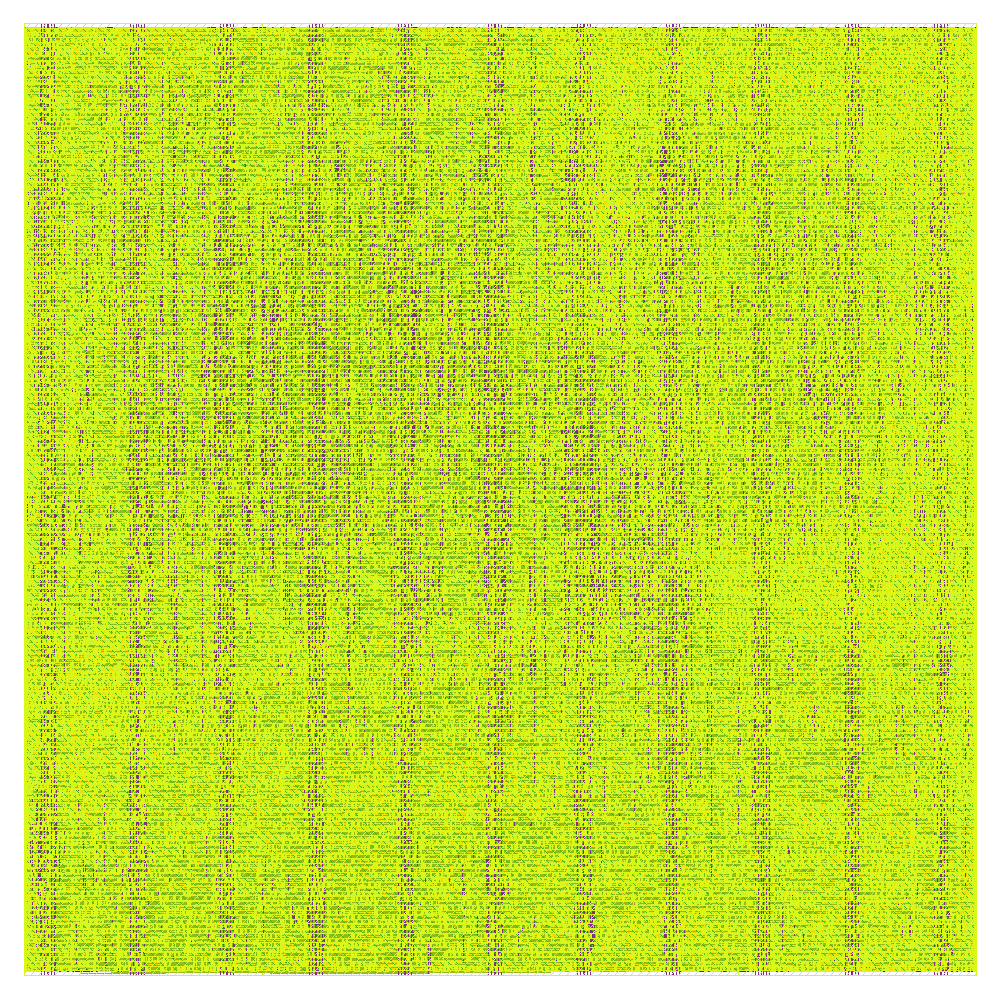

In [52]:
QUARTET = {"gds": "*.gds", "lef": "*.lef", "lib": "**/*.lib", "nl": "*.nl.v"}
print(f"=== build/top -- macro views ({HOST_BUILD}) ===\n")
present = {}
if HOST_BUILD.is_dir():
    for kind, pat in QUARTET.items():
        hits = sorted((HOST_BUILD / kind).glob(pat)) if (HOST_BUILD / kind).is_dir() else []
        present[kind] = bool(hits)
        for h in hits:
            print(f"  {kind:<5} {h.relative_to(HOST_BUILD)}  ({h.stat().st_size / 1024:.0f} KiB)")
        if not hits:
            print(f"  {kind:<5} -- missing --")
    for extra in ("def", "spef", "sdf", "sdc", "spice", "odb"):
        d = HOST_BUILD / extra
        if d.is_dir():
            n = len([p for p in d.rglob('*') if p.is_file()])
            print(f"  {extra:<5} {n} file(s)")
else:
    print(f"  !! {HOST_BUILD} does not exist -- Stage 3 has not run with --save-views-to")

print()
verdict([(f"{k} view present", v) for k, v in present.items()] or [("build dir exists", False)],
        "Macro deliverable set")

renders = sorted((HOST_BUILD / "render").glob("*.png")) if (HOST_BUILD / "render").is_dir() else []
if renders:
    from IPython.display import Image, display
    print(f"\nlayout render: {renders[-1]}")
    display(Image(filename=str(renders[-1]), width=650))

## Stage 4 — Post-synthesis (gate-level) verification (cocotb)

Re-runs the `test-top` cocotb suite from Stage 0, unchanged, against the **actual signed-off gate
netlist** (`build/top/nl/top.nl.v`) plus the real `gf180mcu_fd_sc_mcu7t5v0` standard-cell Verilog
models — not the behavioral RTL. This is the check that answers "does the synthesized, placed-and-
routed design still behave like the RTL," which nothing before this stage can prove: Stage 0 only
proves the RTL is functionally correct, and Stages 1-3's metrics only prove the physical
implementation is legal (DRC/LVS) and timing-clean (STA) — neither proves *functional* equivalence
between RTL and gate netlist.

Compiled with `-DFUNCTIONAL -DUNIT_DELAY=#1` (functional-only cell models, unit delay — **not**
SDF-backannotated timing simulation). This proves logical equivalence under the same test vectors
that passed at the RTL level; it does not by itself prove the design meets timing when clocked at
speed. Runtime is substantially slower than RTL simulation (full standard-cell models vs. behavioral
Verilog) — each `test_top.py` case exercises 1-2 full 512-sample blocks through ~54,000 gate
instances, so budget several minutes per test.

**Prerequisite:** Stage 3 (`S3_SIGNOFF`) must have completed with `--save-views-to build/top`, so
`build/top/nl/top.nl.v` exists.

In [ ]:
RUN_COCOTB_POSTSYNTH = True   # Stage 4: gate-level cocotb regression (post-synthesis netlist)

nl_path = HOST_BUILD / "nl" / "top.nl.v"
ok("signed-off netlist present", nl_path.exists(), str(nl_path))

In [ ]:
GL_RESULTS = {}
if RUN_COCOTB_POSTSYNTH:
    GL_RESULTS["test-top-gl"] = run_cocotb_suite("test-top-gl", do_it=True, log_name="postsynth_test-top-gl.log")
else:
    print("(gate is False) skipping post-synthesis gate-level cocotb -- flip RUN_COCOTB_POSTSYNTH to run it.")

### Stage 4 metrics — post-synthesis (gate-level) verification summary

In [ ]:
print("=== Post-synthesis (gate-level) cocotb verification ===\n")
print(f"  netlist under test : {nl_path}")
print(f"  cell models        : {STD_CELL_LIB} (functional-only, unit-delay)\n")

checks_postsynth = []
r = GL_RESULTS.get("test-top-gl")
if r is None or r["tests"] is None:
    row("test-top-gl", "NOT RUN" if r is None else "no summary parsed")
    checks_postsynth.append(("gate-level test-top ran cleanly", False))
else:
    flag = "" if r["failed"] == 0 and r["rc"] == 0 else "   <-- FAIL"
    row("test-top-gl", f"{r['passed']}/{r['tests']} PASS", f"({r['elapsed_s'] / 60:.1f} min)", flag)
    checks_postsynth.append(("gate-level test-top all tests pass", r["failed"] == 0 and r["rc"] == 0))

print()
print("  Same 8 test cases as Stage 0's RTL-level test-top, now against the gate netlist:")
print("  Case 1 no-fault baseline, Cases 2-4 per-axis fault (X/Y/Z), Case 5 simultaneous 3-axis,")
print("  Case 6 fault-clear, plus the two ITAG structural invariants (9 mag pulses/block,")
print("  no multiplier contention). A pass here means RTL and gate netlist agree on every one.")

print()
POSTSYNTH_GATE = verdict(checks_postsynth, "Stage 4 post-synthesis verification")

### Verification summary — pre-synthesis vs. post-synthesis

The two gates that answer "is this macro functionally correct" at the two points in the flow where
that question can be asked independently: before any tool has touched the RTL, and after the full
synthesis → place & route → signoff pipeline has produced a gate netlist.

In [ ]:
print("=== Pre-synthesis vs. post-synthesis verification ===\n")
row("Stage 0 (pre-synthesis, RTL)",  f"{total_pass}/{total_tests} PASS" if 'total_pass' in dir() else "not run")
r = GL_RESULTS.get("test-top-gl")
row("Stage 4 (post-synthesis, gate-level)",
    f"{r['passed']}/{r['tests']} PASS" if r and r["tests"] is not None else "not run")

print()
verdict([
    ("pre-synthesis (RTL) verification passed",  'PRESYNTH_GATE' in dir() and PRESYNTH_GATE),
    ("post-synthesis (gate-level) verification passed", 'POSTSYNTH_GATE' in dir() and POSTSYNTH_GATE),
], "Full-flow functional verification (pre- and post-synthesis)")

## Appendix — diagnostics

Only needed when a gate above fails. Point `TAG` at the stage you want to dissect.

### A.1 — Report inventory for a stage

In [53]:
TAG = TAG_SIGNOFF     # TAG_SYNTH | TAG_PNR | TAG_SIGNOFF
KEYWORD = None        # e.g. "drc", "lvs", "max", "skew" -- None lists everything

for d in step_dirs(TAG):
    rd = d / "reports"
    if not rd.is_dir():
        continue
    files = [f for f in sorted(rd.rglob("*")) if f.is_file()]
    if KEYWORD:
        files = [f for f in files if KEYWORD.lower() in f.name.lower()]
    if files:
        print(f"### {d.name}")
        for f in files:
            print(f"     {f.relative_to(HOST_RUNS / TAG)}")

### 02-openroad-checkantennas-1
     02-openroad-checkantennas-1/reports/antenna.rpt
     02-openroad-checkantennas-1/reports/antenna_summary.rpt
### 20-magic-drc
     20-magic-drc/reports/drc.magic.lyrdb
     20-magic-drc/reports/drc.magic.rpt
### 26-netgen-lvs
     26-netgen-lvs/reports/lvs.netgen.json
     26-netgen-lvs/reports/lvs.netgen.rpt


### A.2 — Worst setup path in the failing corner

Auto-selects the corner with the worst post-PnR slack and prints the head of its `max.rpt`
(the full launch→capture path with per-cell delay), which is where cell sizing, buffering and
clock-skew problems become visible.

In [54]:
TAG = TAG_SIGNOFF
sta = step_dir(TAG, "stapostpnr") if any("stapostpnr" in d.name for d in step_dirs(TAG)) \
      else step_dir(TAG, "sta")

M = cumulative_metrics(TAG)
ws = corners_of(M, "timing__setup__ws")
worst_corner = min(ws, key=ws.get) if ws else None
print(f"STA step     : {sta.name}")
print(f"worst corner : {worst_corner}  ({ws.get(worst_corner)} ns)\n")

cdir = sta / (worst_corner or "")
rpt  = cdir / "max.rpt"
if rpt.exists():
    lines = rpt.read_text().splitlines()
    n_vio = sum("VIOLATED" in l for l in lines)
    print(f"{rpt}  ({len(lines)} lines, {n_vio} violating path(s) reported)")
    print("report_checks output is sorted worst-first, so the first path below IS the critical path.\n")
    print("\n".join(lines[:175]))
    summary = sta / "summary.rpt"
    if summary.exists():
        print("\n=== summary.rpt ===")
        print(summary.read_text()[:2500])
    vl = cdir / "violator_list.rpt"
    if vl.exists():
        vtxt = vl.read_text().splitlines()
        print(f"\n=== violator_list.rpt ({len(vtxt)} entries) ===")
        print("\n".join(vtxt[:25]))
else:
    print(f"not found: {rpt}\navailable corners: {[p.name for p in sta.iterdir() if p.is_dir()]}")

STA step     : 11-openroad-stapostpnr
worst corner : max_ss_125C_4v50  (11.842442028870462 ns)

/home/kishor/eda/designs/space-jam/librelane/runs/S3_SIGNOFF/11-openroad-stapostpnr/max_ss_125C_4v50/max.rpt  (122395 lines, 0 violating path(s) reported)
report_checks output is sorted worst-first, so the first path below IS the critical path.


report_checks -path_delay max (Setup)
======================= max_ss_125C_4v50 Corner ===================================

Startpoint: _28401_ (rising edge-triggered flip-flop clocked by clk)
Endpoint: _28540_ (rising edge-triggered flip-flop clocked by clk)
Path Group: clk
Path Type: max

Fanout         Cap        Slew       Delay        Time   Description
---------------------------------------------------------------------------------------------
                                  0.000000    0.000000   clock clk (rise edge)
                                  0.000000    0.000000   clock source latency
     2    0.145530    0.000000    0.000000    

### A.3 — Slack distribution across every STA step (pre-PnR → post-PnR)

In [55]:
for tag in (TAG_SYNTH, TAG_PNR, TAG_SIGNOFF):
    if not (HOST_RUNS / tag).is_dir():
        continue
    print(f"=== {tag} ===")
    for d in step_dirs(tag):
        if not re.search(r"sta(prepnr|midpnr|postpnr)", d.name):
            continue
        s = d / "state_out.json"
        if not s.exists():
            continue
        m = json.loads(s.read_text()).get("metrics", {})
        print(f"  {d.name:<34} setup WS {m.get('timing__setup__ws', float('nan')):>9.3f} ns"
              f"   TNS {m.get('timing__setup__tns', float('nan')):>11.2f}"
              f"   hold WS {m.get('timing__hold__ws', float('nan')):>7.3f} ns")

=== S1_SYNTH ===
  12-openroad-staprepnr              setup WS    25.062 ns   TNS        0.00   hold WS   0.077 ns
=== S2_DRT ===
  19-openroad-stamidpnr              setup WS    32.869 ns   TNS        0.00   hold WS   0.130 ns
  24-openroad-stamidpnr-1            setup WS    34.705 ns   TNS        0.00   hold WS   0.297 ns
  26-openroad-stamidpnr-2            setup WS    34.705 ns   TNS        0.00   hold WS   0.344 ns
  31-openroad-stamidpnr-3            setup WS    33.549 ns   TNS        0.00   hold WS   0.348 ns
=== S3_SIGNOFF ===
  11-openroad-stapostpnr             setup WS    11.842 ns   TNS        0.00   hold WS   0.127 ns


### A.4 — Warning census (what the tools complained about)

In [56]:
TAG = TAG_SIGNOFF
M = cumulative_metrics(TAG)
warns = {k.split(":")[-1]: v for k, v in M.items() if k.startswith("flow__warnings__count:")}
for code_id, n in sorted(warns.items(), key=lambda kv: -kv[1]):
    print(f"  {n:>6}  {code_id}")
wl = HOST_RUNS / TAG / "warning.log"
el = HOST_RUNS / TAG / "error.log"
for p in (wl, el):
    if p.exists():
        txt = p.read_text(errors="ignore").strip()
        print(f"\n--- {p.name} ({len(txt.splitlines())} lines) ---")
        print("\n".join(txt.splitlines()[:25]))

    1001  STA-1140
       8  DRT-0120
       8  DRT-0349
       2  GRT-0281
       1  ODB-0220
       1  ORD-0039
       1  GPL-0302
       1  RSZ-0020
       1  CTS-0041

--- warning.log (25 lines) ---
Threshold for Threshold-surpassing long wires is not set. The checker will be skipped.
'VSRC_LOC_FILES' was not given a value, which may make the results of IR drop analysis inaccurate. If you are not integrating a top-level chip for manufacture, you may ignore this warning, otherwise, see the documentation for 'VSRC_LOC_FILES'.
KLAYOUT_DRC_RUNSET is unset. KLayout.DRC may not be supported for the gf180mcuD PDK. This step will be skipped.
The KLayout DRC errors metric was not found. Are you sure the relevant step was run?
Max Slew violations found in the following corners:
* max_ff_n40C_5v50
* max_ss_125C_4v50
* max_tt_025C_5v00
* min_ff_n40C_5v50
* min_ss_125C_4v50
* min_tt_025C_5v00
* nom_ff_n40C_5v50
* nom_ss_125C_4v50
* nom_tt_025C_5v00
Max Cap violations found in the following corn

## Next

Once Stage 3's gate is green (DRC / LVS / XOR / antenna zero, setup **and** hold met on all corners)
**and** Stage 4's gate-level cocotb suite passes, the `top` macro's functional correctness is verified
at both the RTL and gate-netlist level, and `build/top/{gds,lef,lib,nl}` is the deliverable set.

Pad ring and chip top are intentionally **out of scope here** — they belong in a follow-on notebook
that consumes this macro through `MACROS:` + `PDN_MACRO_CONNECTIONS:`, and there is no point wiring
a pad frame around a macro that has not signed off yet.